The local Code Agent (Qwen 2.5-Coder-3B-Instruct)


Before we can run our local Code Agent, we need to install the necessary Python libraries. smolagents is our framework for building agents, while transformers, accelerate, and bitsandbytes are crucial for efficiently loading and running large language models on a GPU. yfinance, seaborn, and matplotlib are data science libraries the agent will use for financial data analysis and visualization.


In [ ]:
# ==========================================
# Install Dependencies
# ==========================================
# We need 'accelerate' and 'bitsandbytes' to load the model efficiently on the GPU.
# Added 'duckduckgo_search' to enable web search capabilities for the agent.
!pip install -q smolagents transformers accelerate bitsandbytes yfinance seaborn matplotlib duckduckgo_search


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 141.1 MB/s eta 0:00:00


Now we'll load the Qwen 2.5 Coder 3B model. This model is specifically designed for code generation tasks. We're using TransformersModel from smolagents to load it. device_map='auto' ensures the model automatically utilizes the available T4 GPU, and torch_dtype=torch.float16 reduces memory footprint by using half-precision floating-point numbers. max_new_tokens is set to allow for longer code outputs.

In [ ]:
# ==========================================
# Load the 3B Model (Lightweight & Fast)
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...")

# We use the 3B-Instruct model.
# device_map="auto" finds the Colab GPU.
# torch_dtype=torch.float16 cuts memory usage in half.
model = TransformersModel(
    model_id="Qwen/Qwen2.5-Coder-3B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=2048  # Give it space to write longer scripts
)

print("✅ 3B Model loaded on GPU! Ready for coding.")

⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ 3B Model loaded on GPU! Ready for coding.


Error saving agent: cannot pickle '_thread.lock' object


With the model loaded, we can now initialize our CodeAgent. We provide it with the loaded model and specify additional_authorized_imports. This list tells the agent which Python libraries it is allowed to use when generating and executing code. Crucially, we don't give it predefined tools; instead, it writes its own code using these authorized libraries, making it highly flexible.




In [ ]:
# ==========================================
# Initialize the Agent
# ==========================================

# We authorize the agent to use specific data science libraries, and now also a web search library.
agent = CodeAgent(
    tools=[], # We don't need pre-made tools; the agent writes its own code.
    model=model,
    max_steps=3,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "seaborn",
        "matplotlib.pyplot",
        "duckduckgo_search" # Added for web search capabilities
    ]
)


Coding task:

CodeAgent will -Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank Portfolio (JPM, BAC, C) using yfinance, calculate daily returns and sharpe ratios, and then visusalise the results as a bar chart comparing the sharpe ratios fo all 6 companies using seaborn. The agent will interpret this prompt, write the Python code, and then execute it to produce the sharpe_comparison.png file.

Financial Math:

Calculate the Daily Returns for each stock.
Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252)).
Visualization:

Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.

Color code the bars: Green for Tech, Blue for Banks.

Output: Save the chart as sharpe_comparison.png.

🤖 Agent is coding... (Watch the 'Thought' process below)


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 1. Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank       │
│ Portfolio (JPM, BAC, C) using yfinance.                                                                         │
│ 2. Create a single DataFrame with these close prices.                                                           │
│ 3. Calculate the daily returns of each stock                                                                    │
│ 4. Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev  │
│ of Daily Returns * sqrt(252))                                                                                   │
│ 5. Plot a Bar chart comparing the sharpe ratios of all 6 companies using seaborn with annotations.              │
│ 6. Color code the bars: Green for Tech, Blue for Banks.                                                         │
│ 7. Save the plot as 'sharpe_comparison.png'.                                                                    │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
                                                                                                                   
  # Step 1: Download daily closing prices for the last 180 days                                                    
  tech_stocks = ['NVDA', 'AAPL', 'MSFT']                                                                           
  bank_stocks = ['JPM', 'BAC', 'C']                                                                                
                                                                                                                   
  tech_prices = yf.download(tech_stocks, period='180d')['Close']                                                   
  bank_prices = yf.download(bank_stocks, period='180d')['Close']                                                   
                                                                                                                   
  # Step 2: Combine these prices into a single DataFrame                                                           
  combined_prices = pd.concat([tech_prices, bank_prices], axis=1)                                                  
  combined_prices.columns = tech_stocks + bank_stocks                                                              
                                                                                                                   
  # Step 3: Calculate the daily returns for each stock                                                             
  daily_returns = combined_prices.pct_change()                                                                     
                                                                                                                   
  # Step 4: Compute the Sharpe Ratio for each stock                                                                
  risk_free_rate = 0                                                                                               
  sharpe_ratios = daily_returns.mean() / daily_returns.std() * (252**0.5)                                          
                                                                                                                   
  # Step 5: Plot a bar chart comparing the Sharpe Ratios with color coding for Tech and Banks                      
  plt.figure(figsize=(10, 6))                                                                                      
  sns.barplot(x=sharpe_ratios.index, y=sharpe_ratios.values, palette=['green', 'blue'])                            
  plt.title('Sharpe Ratios of Tech and Bank Stocks')                                                               
  plt.xlabel('Stock')                                                                                              
  plt.ylabel('Sharpe Ratio')                                                                                       
  plt.xticks(rotation=45)                                                                                          
  plt.tight_layout()                                                                                               
                                                                                                                   
  # Step 6: Save the plot as 'sharpe_comparison.png'                                                               
  plt.savefig('sharpe_comparison.png')                   

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an u

Final answer: Plot saved as 'sharpe_comparison.png'

[Step 1: Duration 37.06 seconds| Input tokens: 2,203 | Output tokens: 528]

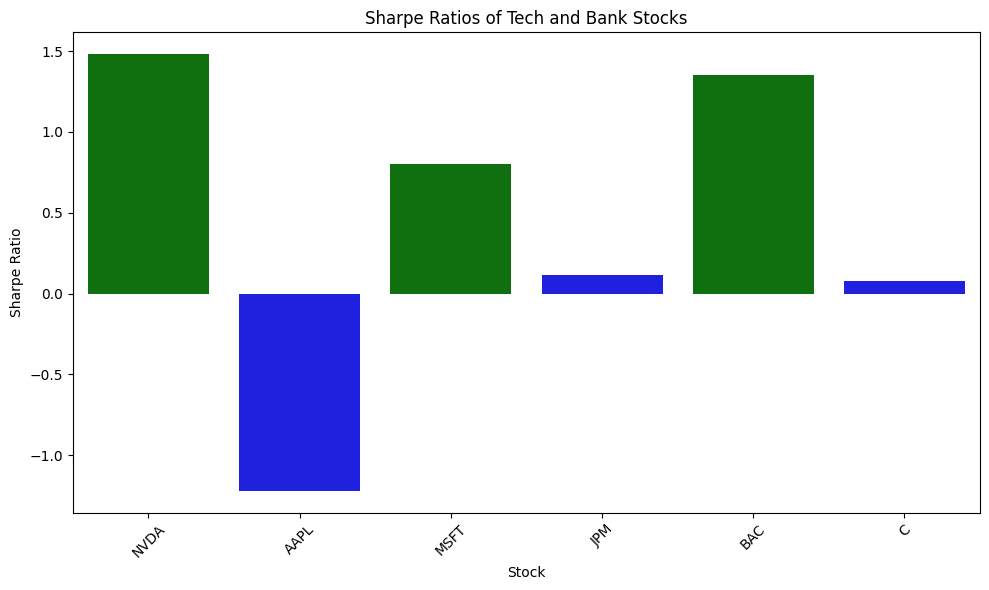

In [ ]:
# ==========================================
# Execute the sharpe ratio barchart Task
# ==========================================
# We give it a complex multi-step instruction.
task_prompt = """
1. Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank Portfolio (JPM, BAC, C) using yfinance.
2. Create a single DataFrame with these close prices.
3. Calculate the daily returns of each stock
4. Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252))
5. Plot a Bar chart comparing the sharpe ratios of all 6 companies using seaborn with annotations.
6. Color code the bars: Green for Tech, Blue for Banks.
7. Save the plot as 'sharpe_comparison.png'.
"""

print("🤖 Agent is coding... (Watch the 'Thought' process below)")
result = agent.run(task_prompt,stream=False)